# Optimización convencional vs residual

Pregunta: ¿Cómo cambia la dinámica de optimización cuando se agregan conexiones residuales?
- Analizando el Notebook, pude observar que al agregar conexiones residuales cambia la dinámica al introducir una ruta de identidad que ayuda a preservar el flujo de gradiente y estabilizar el aprendizaje, en lugar de depender solo de la cadena completa de transformaciones F(x).

Dataset: CIFAR-10.

Variables controladas: división de datos, optimizador, épocas, canales, bloques, convoluciones principales, BatchNorm, clasificador e inicialización.

Diferencia: el bloque convencional usa `y = F(x)`; el bloque residual usa `y = F(x) + S(x)`.

Hipótesis: las conexiones residuales pueden hacer más estable la optimización.

También observaremos cómo cambia la señal de aprendizaje en bloques tempranos. El objetivo no es encontrar el gradiente más grande, sino ver si las normas siguen siendo utilizables a través de la profundidad.

**Advertencia:** Una norma de gradiente mayor no implica automáticamente una mejor optimización. También importan la estabilidad, la dirección de las actualizaciones y la evolución de la pérdida.

Una sola ejecución no demuestra superioridad universal.


In [1]:
import random
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

def set_seed(seed=7):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(7)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

train_subset_size = 2500
val_subset_size = 500
batch_size = 32

cifar_mean = (0.4914, 0.4822, 0.4465)
cifar_std = (0.2470, 0.2435, 0.2616)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomAffine(scale=(0.8, 1.2), degrees=10, shear=10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])

val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(cifar_mean, cifar_std),
])

train_source_dataset = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=train_transform,
)

val_source_dataset = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=val_transform,
)

split_generator = torch.Generator().manual_seed(7)
indices = torch.randperm(
    len(train_source_dataset),
    generator=split_generator,
).tolist()

train_indices = indices[:train_subset_size]
val_indices = indices[train_subset_size:train_subset_size + val_subset_size]

train_dataset = Subset(train_source_dataset, train_indices)
val_dataset = Subset(val_source_dataset, val_indices)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
)

fixed_inputs, fixed_targets = next(iter(train_loader))

print(f"Dataset: CIFAR-10")
print(f"Dispositivo: {device}")
print(f"Muestras de entrenamiento: {len(train_dataset)}")
print(f"Muestras de validación: {len(val_dataset)}")
print(f"Tamaño de lote: {batch_size}")
print(f"Lote fijo para gradientes: {fixed_inputs.shape[0]} muestras")

Dataset: CIFAR-10
Dispositivo: cpu
Muestras de entrenamiento: 2500
Muestras de validación: 500
Tamaño de lote: 32
Lote fijo para gradientes: 32 muestras


In [2]:
class PlainBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=False)
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)
        return out


class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            stride=stride,
            padding=1,
            bias=False,
        )
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=False)
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            stride=1,
            padding=1,
            bias=False,
        )
        self.bn2 = nn.BatchNorm2d(out_channels)

        if in_channels == out_channels and stride == 1:
            self.shortcut = nn.Identity()
        else:
            self.shortcut = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1,
                stride=stride,
                bias=False,
            )

    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out = out + self.shortcut(x)
        out = self.relu(out)
        return out

In [3]:
class SmallCNN(nn.Module):
    def __init__(self, block_class):
        super().__init__()
        self.stage1 = nn.Sequential(
            block_class(3, 16, stride=1),
            block_class(16, 16, stride=1),
        )
        self.stage2 = nn.Sequential(
            block_class(16, 32, stride=2),
            block_class(32, 32, stride=1),
        )
        self.stage3 = nn.Sequential(
            block_class(32, 64, stride=2),
            block_class(64, 64, stride=1),
        )
        self.stage4 = nn.Sequential(
            block_class(64, 128, stride=2),
            block_class(128, 128, stride=1),
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(128, 10)
        self.initialize_weights()

    def initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(
                    module.weight,
                    mode="fan_out",
                    nonlinearity="relu",
                )
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.ones_(module.weight)
                nn.init.zeros_(module.bias)
            elif isinstance(module, nn.Linear):
                nn.init.normal_(module.weight, mean=0.0, std=0.01)
                nn.init.zeros_(module.bias)

    def forward(self, x):
        out = self.stage1(x)
        out = self.stage2(out)
        out = self.stage3(out)
        out = self.stage4(out)
        out = self.pool(out)
        out = torch.flatten(out, 1)
        out = self.classifier(out)
        return out

def count_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)

set_seed(7)
plain_model = SmallCNN(PlainBlock).to(device)
set_seed(7)
residual_model = SmallCNN(ResidualBlock).to(device)

print(f"Parámetros del modelo convencional: {count_parameters(plain_model):,}")
print(f"Parámetros del modelo residual: {count_parameters(residual_model):,}")

with torch.no_grad():
    dummy_input = torch.randn(2, 3, 32, 32).to(device)
    plain_output = plain_model(dummy_input)
    residual_output = residual_model(dummy_input)

assert plain_output.shape == torch.Size([2, 10])
assert residual_output.shape == torch.Size([2, 10])

Parámetros del modelo convencional: 687,930
Parámetros del modelo residual: 698,730


In [4]:
def evaluate(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            current_batch_size = labels.size(0)
            total_loss += loss.item() * current_batch_size
            total_correct += (outputs.argmax(dim=1) == labels).sum().item()
            total_samples += current_batch_size

    average_loss = total_loss / total_samples
    accuracy = total_correct / total_samples
    return average_loss, accuracy

def train_model(
    model,
    train_loader,
    val_loader,
    epochs,
    device,
):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(
        model.parameters(),
        lr=0.05,
        momentum=0.9,
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
    }

    for epoch in range(1, epochs + 1):
        model.train()
        total_train_loss = 0.0
        total_train_samples = 0

        for images, labels in train_loader:
            images = images.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            current_batch_size = labels.size(0)
            total_train_loss += loss.item() * current_batch_size
            total_train_samples += current_batch_size

        train_loss = total_train_loss / total_train_samples
        val_loss, val_accuracy = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)

        print(
            f"Época {epoch}/{epochs} | "
            f"pérdida entrenamiento: {train_loss:.4f} | "
            f"pérdida validación: {val_loss:.4f} | "
            f"exactitud validación: {val_accuracy:.3f}"
        )

    return history

def collect_gradient_norms(
    model,
    inputs,
    targets,
    criterion,
    device,
):
    inputs = inputs.to(device)
    targets = targets.to(device)

    model.train()
    model.zero_grad(set_to_none=True)

    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()

    blocks = (
        list(model.stage1)
        + list(model.stage2)
        + list(model.stage3)
    )

    gradient_norms = []
    for block_index, block in enumerate(blocks, start=1):
        gradient = block.conv1.weight.grad
        if gradient is None:
            raise RuntimeError(
                f"El gradiente de conv1 no existe en el bloque {block_index}."
            )
        gradient_norms.append(gradient.norm(p=2).item())

    loss_value = loss.item()
    return loss_value, gradient_norms

In [5]:
num_epochs = 20
criterion = nn.CrossEntropyLoss()

set_seed(7)
plain_model = SmallCNN(PlainBlock).to(device)
set_seed(7)
residual_model = SmallCNN(ResidualBlock).to(device)

plain_initial_loss, plain_gradients_before = collect_gradient_norms(
    plain_model,
    fixed_inputs,
    fixed_targets,
    criterion,
    device,
)
residual_initial_loss, residual_gradients_before = collect_gradient_norms(
    residual_model,
    fixed_inputs,
    fixed_targets,
    criterion,
    device,
)

print("Diagnóstico antes del entrenamiento:")
print(
    f"Modelo convencional | pérdida: {plain_initial_loss:.4f} | "
    f"gradiente bloque 1: {plain_gradients_before[0]:.6f} | "
    f"gradiente bloque 6: {plain_gradients_before[-1]:.6f}"
)
print(
    f"Modelo residual | pérdida: {residual_initial_loss:.4f} | "
    f"gradiente bloque 1: {residual_gradients_before[0]:.6f} | "
    f"gradiente bloque 6: {residual_gradients_before[-1]:.6f}"
)

set_seed(11)
plain_history = train_model(
    plain_model,
    train_loader,
    val_loader,
    num_epochs,
    device,
)

set_seed(11)
residual_history = train_model(
    residual_model,
    train_loader,
    val_loader,
    num_epochs,
    device,
)

plain_final_loss, plain_gradients_after = collect_gradient_norms(
    plain_model,
    fixed_inputs,
    fixed_targets,
    criterion,
    device,
)
residual_final_loss, residual_gradients_after = collect_gradient_norms(
    residual_model,
    fixed_inputs,
    fixed_targets,
    criterion,
    device,
)

plain_final_train_loss = plain_history["train_loss"][-1]
plain_final_val_loss = plain_history["val_loss"][-1]
plain_final_val_accuracy = plain_history["val_accuracy"][-1]

residual_final_train_loss = residual_history["train_loss"][-1]
residual_final_val_loss = residual_history["val_loss"][-1]
residual_final_val_accuracy = residual_history["val_accuracy"][-1]

print("Resumen final:")
print(
    f"Modelo convencional | pérdida entrenamiento: {plain_final_train_loss:.4f} | "
    f"pérdida validación: {plain_final_val_loss:.4f} | "
    f"exactitud validación: {plain_final_val_accuracy:.3f}"
)
print(
    f"Modelo residual | pérdida entrenamiento: {residual_final_train_loss:.4f} | "
    f"pérdida validación: {residual_final_val_loss:.4f} | "
    f"exactitud validación: {residual_final_val_accuracy:.3f}"
)
print(
    f"Pérdida diagnóstica final | modelo convencional: {plain_final_loss:.4f} | "
    f"modelo residual: {residual_final_loss:.4f}"
)
print("**Advertencia:** Esta comparación ilustra una dinámica de optimización para una semilla y una configuración específicas.")

Diagnóstico antes del entrenamiento:
Modelo convencional | pérdida: 2.3012 | gradiente bloque 1: 0.404995 | gradiente bloque 6: 0.114153
Modelo residual | pérdida: 2.3080 | gradiente bloque 1: 0.230000 | gradiente bloque 6: 0.114884
Época 1/20 | pérdida entrenamiento: 2.2652 | pérdida validación: 2.1415 | exactitud validación: 0.192
Época 2/20 | pérdida entrenamiento: 2.0692 | pérdida validación: 2.2315 | exactitud validación: 0.220
Época 3/20 | pérdida entrenamiento: 2.0195 | pérdida validación: 2.2086 | exactitud validación: 0.196
Época 4/20 | pérdida entrenamiento: 1.9298 | pérdida validación: 1.9718 | exactitud validación: 0.248
Época 5/20 | pérdida entrenamiento: 1.9039 | pérdida validación: 2.0062 | exactitud validación: 0.252
Época 6/20 | pérdida entrenamiento: 1.8500 | pérdida validación: 2.1426 | exactitud validación: 0.234
Época 7/20 | pérdida entrenamiento: 1.8309 | pérdida validación: 1.8612 | exactitud validación: 0.288
Época 8/20 | pérdida entrenamiento: 1.8160 | pérdida 

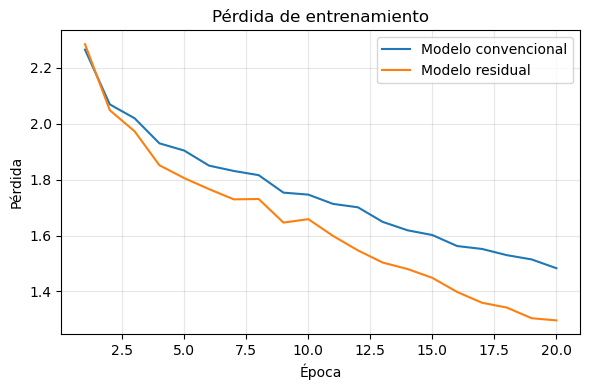

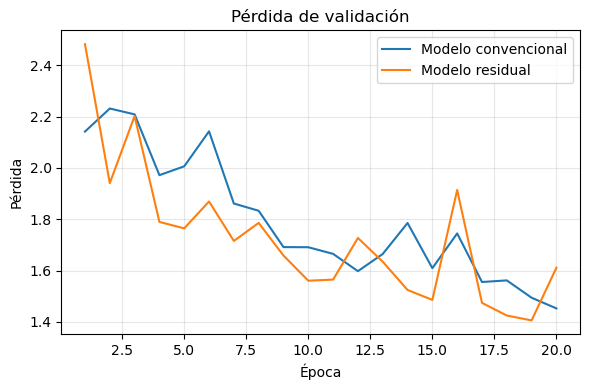

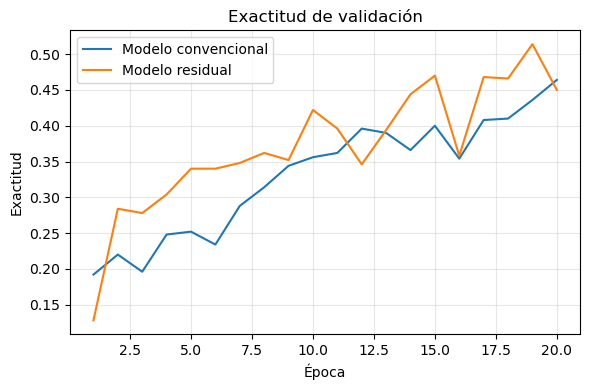

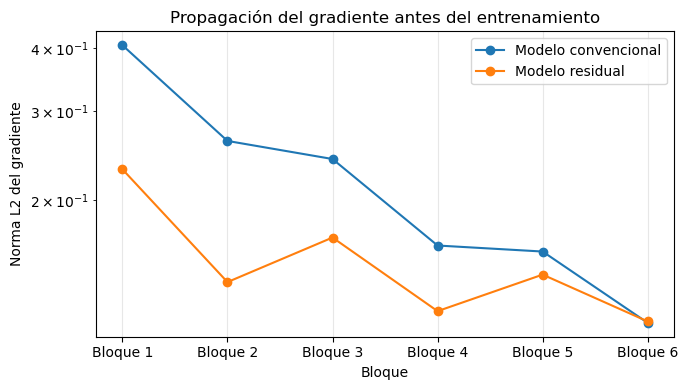

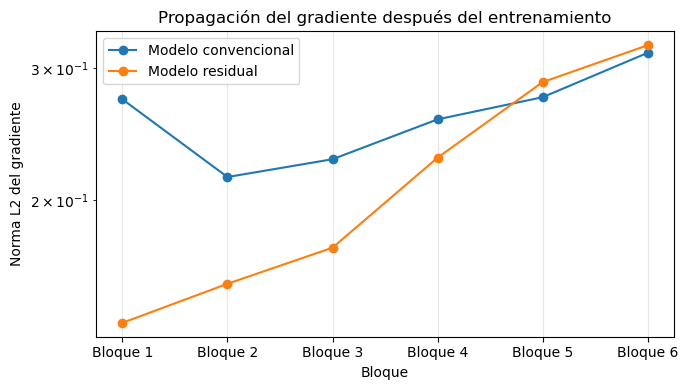

In [6]:
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(6, 4))
plt.plot(epochs, plain_history["train_loss"], label="Modelo convencional")
plt.plot(epochs, residual_history["train_loss"], label="Modelo residual")
plt.title("Pérdida de entrenamiento")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, plain_history["val_loss"], label="Modelo convencional")
plt.plot(epochs, residual_history["val_loss"], label="Modelo residual")
plt.title("Pérdida de validación")
plt.xlabel("Época")
plt.ylabel("Pérdida")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(epochs, plain_history["val_accuracy"], label="Modelo convencional")
plt.plot(epochs, residual_history["val_accuracy"], label="Modelo residual")
plt.title("Exactitud de validación")
plt.xlabel("Época")
plt.ylabel("Exactitud")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

block_numbers = range(1, 7)
block_labels = [f"Bloque {block_number}" for block_number in block_numbers]

plt.figure(figsize=(7, 4))
plt.plot(block_numbers, plain_gradients_before, marker="o", label="Modelo convencional")
plt.plot(block_numbers, residual_gradients_before, marker="o", label="Modelo residual")
plt.title("Propagación del gradiente antes del entrenamiento")
plt.xlabel("Bloque")
plt.ylabel("Norma L2 del gradiente")
plt.xticks(block_numbers, block_labels)
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(block_numbers, plain_gradients_after, marker="o", label="Modelo convencional")
plt.plot(block_numbers, residual_gradients_after, marker="o", label="Modelo residual")
plt.title("Propagación del gradiente después del entrenamiento")
plt.xlabel("Bloque")
plt.ylabel("Norma L2 del gradiente")
plt.xticks(block_numbers, block_labels)
plt.yscale("log")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()